# 2D Grating Coupler: Wavelength Sweep

A parallel sweep of the design wavelength for the **2D XZ grating-coupler**
workflow (see `meep_2d_xz_gc.ipynb` for the single-shot version).

We sweep over `1.54, 1.55, 1.56` µm. At each wavelength both the coupler
geometry (`grating_coupler_elliptical(wavelength=...)` re-tunes the grating
pitch/teeth) **and** the Gaussian-beam source are set to that wavelength. All
simulations run on the GDSFactory+ cloud via the non-blocking API, then we
overlay the coupling S-parameter for every wavelength in a single plot.

**Requirements:** GDSFactory+ account for cloud simulation.

### Define the sweep

In [1]:
wavelengths_um = [1.54, 1.55, 1.56]

### Build a grating coupler + feed straight for a given wavelength

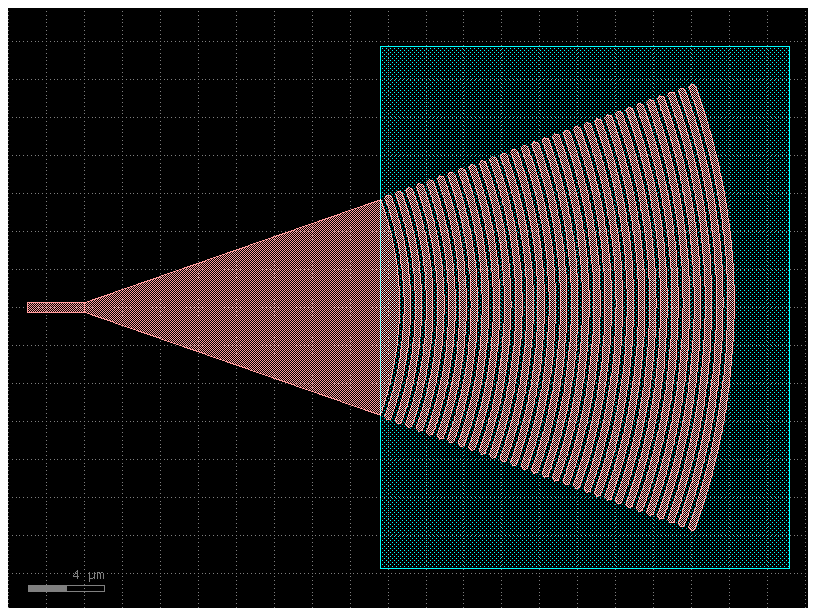

In [2]:
import gdsfactory as gf

gf.gpdk.PDK.activate()


def make_component(wavelength: float) -> gf.Component:
    """Grating coupler tuned to ``wavelength`` plus a 3 µm feed straight."""
    c = gf.Component()
    gc = gf.components.grating_coupler_elliptical(
        wavelength=wavelength, fiber_angle=0.0
    )
    gc_r = c.add_ref(gc)
    s_r = c.add_ref(gf.components.straight(length=3))
    s_r.connect("o1", gc_r.ports["o1"])
    c.add_port("o2", port=s_r.ports["o2"])
    return c


make_component(wavelengths_um[len(wavelengths_um) // 2])  # preview mid-sweep design

### Configure one XZ 2D simulation per wavelength

Same XZ setup as `meep_2d_xz_gc.ipynb`, but the coupler geometry and the
`source_fiber(wavelength=...)` are both varied per point. `save_animation=False`
keeps the sweep light since we only need S-params.

In [3]:
from gsim import meep
from gsim.common.stack import get_stack
from gsim.meep.models.api import Material

stack = get_stack()  # auto-detects active PDK

sims = []
for wl in wavelengths_um:
    c = make_component(wl)

    sim = meep.Simulation()

    sim.geometry(component=c, stack=stack)
    sim.materials = {
        "si": Material(refractive_index=3.47),
        "SiO2": Material(refractive_index=1.44),
    }

    sim.solver(resolution=25, mode="2d", y_cut="auto", save_animation=False)
    sim.solver.stop_when_energy_decayed()

    sim.source_fiber(
        x=25.0,
        z=2,
        angle_deg=-6.0,
        waist=5.2,
        wavelength=wl,
        wavelength_span=0.06,
        polarization="TE",
    )

    sim.monitors = ["o2"]
    sim.domain(pml=1.0, margin_x=0.5, margin_y=0.5, margin_z=(1.5, 0))
    sim.num_freqs = 21

    sims.append(sim)

print(f"Configured {len(sims)} simulations for wavelengths {wavelengths_um}")

Configured 3 simulations for wavelengths [1.54, 1.55, 1.56]


### Upload and start all jobs (non-blocking)

In [4]:
job_ids = [sim.run(wait=False) for sim in sims]
print(f"Started {len(job_ids)} jobs: {job_ids}")

Job started: meep-5d9d2213


Job started: meep-32266448


Job started: meep-2ca61b91
Started 3 jobs: ['019f3855-df37-7752-b70f-266cc65b5169', '019f3855-eac9-79c2-aedf-14b846c03c2a', '019f3855-f46f-7a81-8a53-d22ae7c6b747']


### Wait for all jobs to complete

In [5]:
import gsim

results = gsim.wait_for_results(job_ids)

Waiting for 3 jobs...
  meep-5d9d2213                  completed    4m 48s
  meep-32266448                  completed    4m 50s
  meep-2ca61b91                  completed    4m 42s


Extracting results.tar.gz...
Downloaded 4 files to sim-data-meep-5d9d2213


Extracting results.tar.gz...
Downloaded 4 files to sim-data-meep-32266448


Extracting results.tar.gz...
Downloaded 4 files to sim-data-meep-2ca61b91


### Overlay coupling S-parameter vs wavelength

The fiber source produces a single transmission S-parameter (`S10`) from the
beam into the feed waveguide `o2`. We overlay it in dB for every design
wavelength; each sim covers a small band around its center.

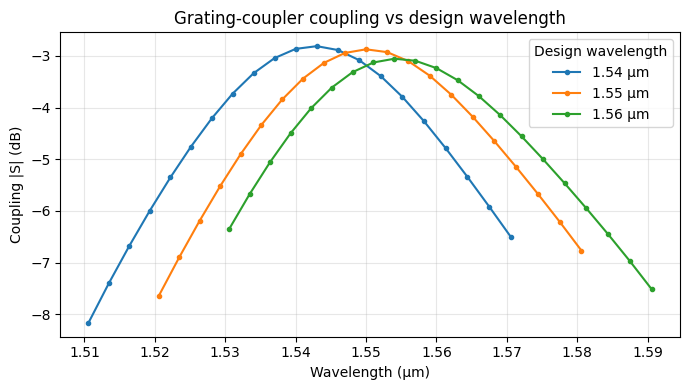

In [6]:
import math

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))

for wl, sp in zip(wavelengths_um, results, strict=True):
    key = next(iter(sp.s_params))  # single transmission param, e.g. "S10"
    db = [20 * math.log10(abs(v)) if abs(v) > 0 else -100 for v in sp.s_params[key]]
    ax.plot(sp.wavelengths, db, ".-", label=f"{wl:.2f} µm")

ax.set(
    xlabel="Wavelength (µm)",
    ylabel="Coupling |S| (dB)",
    title="Grating-coupler coupling vs design wavelength",
)
ax.legend(title="Design wavelength")
ax.grid(True, alpha=0.3)
fig.tight_layout()